# 📚 Scikit-learn 공식 문서 완벽 가이드: `sklearn.datasets.load_iris`
> **공식 문서 원문**: [scikit-learn load_iris documentation](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html#sklearn.datasets.load_iris)

---

### 💡 이 노트북의 학습 목적
데이터 분석이나 머신러닝 모델링 코드를 무작정 작성하기 전에, **우리가 다룰 데이터셋을 불러오는 공식 함수 `load_iris()`의 구조와 파라미터(옵션), 반환 객체의 특성**을 기초부터 차근차근 뜯어보고 이해하는 문서 해설 노트북입니다.

*파이썬이나 데이터 처리가 처음이신 분들도 쉽게 이해하실 수 있도록 코드 한 줄 한 줄의 의도와 동작 원리를 설명합니다.*

---

### 📋 목차
1. **라이브러리 불러오기 (Import)**: 도구 준비 및 모듈 개념 이해
2. **기본 호출과 `Bunch` 객체 이해**: 아무 옵션 없이 호출했을 때 반환되는 객체의 구조
3. **`Bunch` 객체의 6가지 핵심 속성(Attribute) 뜯어보기**:
   - `DESCR`: 데이터셋 공식 설명서
   - `feature_names`: 꽃의 4가지 측정 항목 이름
   - `target_names`: 맞혀야 할 3가지 붓꽃 품종 이름
   - `data`: 150송이 꽃의 치수 행렬 (문제집 $X$)
   - `target`: 각 꽃의 품종 번호 (정답지 $y$)
   - `filename`: 데이터 파일 저장 경로
4. **공식 문서 예제(Examples) 따라해보기**: 샘플 인덱스로 품종 이름 조회
5. **2가지 핵심 파라미터(매개변수) 활용법**:
   - `as_frame=True`: 친숙한 엑셀 표(Pandas DataFrame)로 받기
   - `return_X_y=True`: 문제집($X$)과 정답지($y$)만 분리해서 받기
   - `as_frame=True` + `return_X_y=True` 조합
6. **핵심 요약 정리표**
7. **4개 특성과 Target의 상관관계 분석 및 시각화 (Heatmap & EDA)**:
   - `7-1`. 상관행렬(Correlation Matrix) 계산 및 Target 상관계수 확인
   - `7-2`. 전체 상관관계 히트맵 (Correlation Heatmap) 시각화
   - `7-3`. Target(품종)과의 상관계수 비교 막대 그래프
   - `7-4`. 품종(Target)별 4개 특성 분포 비교 (Boxplot & Stripplot)
   - `7-5`. 핵심 특성 산점도 및 산점도 행렬 (Scatter & Pairplot)
   - `7-6`. 상관관계 분석 핵심 인사이트 & 머신러닝 연계 가이드
8. **상관관계 분석 기반 머신러닝 분류 모델 구축 및 평가**:
   - `8-1`. 데이터 분할 (Train-Test Split & 계층적 샘플링)
   - `8-2`. 의사결정나무(Decision Tree) 모델 학습 및 분류
   - `8-3`. 트리 규칙 시각화(plot_tree) & 특성 중요도(Feature Importance)
   - `8-4`. 오차 행렬(Confusion Matrix) 및 분류 성적표(Classification Report)
   - `8-5`. 2대 핵심 특성 기반 2D 결정 경계면(Decision Boundary) 시각화
   - `8-6`. 다중 머신러닝 모델 벤치마크 (5개 알고리즘 비교)
   - `8-7`. 완성된 모델 파일 저장(`joblib`) 및 새로운 꽃 샘플 예측 실습

## 1. 라이브러리 불러오기 (Import)

### 📌 초보자를 위한 파이썬 개념: `import`란?
파이썬에서는 다른 개발자나 연구자들이 미리 잘 만들어둔 기능들을 '도구 상자(라이브러리 또는 패키지)' 형태로 가져와서 쓸 수 있습니다.
- **`sklearn` (Scikit-learn)**: 파이썬에서 가장 널리 쓰이는 머신러닝 전용 표준 라이브러리입니다.
- **`sklearn.datasets`**: 머신러닝 학습과 실습을 위해 무료로 제공하는 내장 데이터셋(Toy datasets) 모음입니다.
- **`load_iris`**: 그중 가장 유명한 '붓꽃(Iris) 데이터셋'을 메모리로 불러오는 전용 함수입니다.
- **`pandas`**: 데이터를 엑셀 시트처럼 행과 열이 있는 표(DataFrame)로 다루게 해주는 라이브러리입니다.
- **`numpy`**: 대량의 숫자와 행렬 계산을 빠르게 처리해주는 라이브러리입니다.

In [1]:
# [셀 의도] 사이킷런의 load_iris 함수와 데이터 처리를 위한 pandas, numpy를 불러옵니다.
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np

print("✅ 라이브러리 불러오기 완료!")

✅ 라이브러리 불러오기 완료!


## 2. `load_iris()` 기본 호출과 `Bunch` 객체 이해하기

공식 문서의 함수 정의(Signature)를 보면 다음과 같이 나와 있습니다:
```python
sklearn.datasets.load_iris(*, return_X_y=False, as_frame=False)
```
- 괄호 안의 옵션들 뒤에 `=False`라고 적혀 있는 것은 **기본값(Default)**입니다.
- 즉, 아무런 옵션도 전달하지 않고 `load_iris()`라고만 실행하면 `return_X_y=False`, `as_frame=False`가 적용됩니다.

### 📌 `Bunch` 객체란 무엇인가요?
- 기본 형태로 호출하면 `Bunch`라는 특수한 타입의 객체가 반환됩니다.
- **초보자 눈높이 설명**: `Bunch`는 파이썬의 **딕셔너리(Dictionary)**와 똑같습니다!
  - 딕셔너리처럼 `키(Key): 값(Value)` 형태로 여러 정보가 하나의 바구니에 담겨 있습니다.
  - 일반 딕셔너리와의 차이점은, 딕셔너리 문법인 `iris['data']`뿐만 아니라 점(`.`)을 찍어서 `iris.data`처럼 속성(attribute) 형태로도 편리하게 접근할 수 있다는 점입니다.

In [2]:
# [셀 의도] 아무 옵션 없이 load_iris()를 실행하고, 반환된 객체의 타입과 담겨있는 키(Key) 목록을 확인합니다.
iris = load_iris()

# 1. 반환된 결과물의 자료형 확인
print("1. 반환 객체의 타입:", type(iris))

# 2. Bunch 객체 안에 어떤 정보들이 들어있는지 키(Key) 확인
print("\n2. iris 객체가 담고 있는 키(Keys) 목록:")
print(list(iris.keys()))

1. 반환 객체의 타입: <class 'sklearn.utils._bunch.Bunch'>

2. iris 객체가 담고 있는 키(Keys) 목록:
['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']


위 키(keys) 목록에서 확인할 수 있듯, `iris`라는 바구니 안에는 다음과 같은 핵심 데이터들이 정리되어 들어있습니다:
1. `DESCR`: 데이터셋에 대한 상세한 설명서 (Description)
2. `feature_names`: 꽃을 측정한 4가지 항목(특성)의 이름
3. `target_names`: 맞혀야 할 3가지 붓꽃 품종의 실제 이름
4. `data`: 150송이 붓꽃의 4가지 측정 수치 (문제집 $X$)
5. `target`: 150송이 붓꽃 각각의 품종 번호 0, 1, 2 (정답지 $y$)
6. `filename`: 내 컴퓨터에 저장된 원본 데이터 파일의 위치

이제 이 6가지 속성을 하나씩 자세히 살펴보겠습니다.

### 3-1. `DESCR` (데이터셋 설명서 확인하기)
- 공식 문서에서도 가장 먼저 읽어보길 권장하는 데이터셋 설명서(Description)입니다.
- 영국의 통계학자 로널드 피셔(R.A. Fisher)가 1936년에 발표한 유명한 논문에서 사용된 데이터셋입니다.
- 총 150개의 샘플이 있고, 3개의 품종이 각각 50개씩 정확히 균등하게 들어있으며, 결측치(Missing Values)가 0개라는 중요한 정보가 적혀 있습니다.

In [3]:
# [셀 의도] iris.DESCR의 내용을 출력하여 데이터셋의 배경, 샘플 수, 단위 등을 확인합니다.
# (내용이 길기 때문에 핵심 요약 통계가 담긴 앞부분 1,100자만 출력합니다)
print(iris.DESCR[:1100])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

### 3-2. `feature_names` (꽃의 4가지 측정 항목 이름)
- 꽃의 어떤 부위를 측정한 것인지 4개 특성(컬럼)의 이름을 보여줍니다.
- 4가지 항목:
  1. `sepal length (cm)`: 꽃받침(sepal)의 길이
  2. `sepal width (cm)`: 꽃받침(sepal)의 너비
  3. `petal length (cm)`: 꽃잎(petal)의 길이
  4. `petal width (cm)`: 꽃잎(petal)의 너비
- *모든 측정 단위는 센티미터(cm)입니다.*

In [4]:
# [셀 의도] 붓꽃의 4가지 측정 특성(Feature) 이름을 확인합니다.
print("특성 개수:", len(iris.feature_names))
print("특성 이름 목록:")
for i, name in enumerate(iris.feature_names):
    print(f"  [{i}] {name}")

특성 개수: 4
특성 이름 목록:
  [0] sepal length (cm)
  [1] sepal width (cm)
  [2] petal length (cm)
  [3] petal width (cm)


### 3-3. `target_names` (맞춰야 할 붓꽃의 3가지 품종 이름)
- 데이터셋에 등장하는 3가지 붓꽃 품종의 영문 이름입니다:
  - `setosa`: 세토사
  - `versicolor`: 버시컬러
  - `virginica`: 버지니카
- 컴퓨터 모델은 문자열을 직접 다루기보다 숫자를 좋아하기 때문에, 각각 `0`, `1`, `2`라는 번호(Label)를 부여받게 됩니다.

In [5]:
# [셀 의도] 맞혀야 할 3개 품종(클래스)의 이름과 배정된 번호를 확인합니다.
print("품종(Target) 개수:", len(iris.target_names))
print("품종 이름 목록:")
for num, name in enumerate(iris.target_names):
    print(f"  - 번호 {num} => '{name}' 품종")

품종(Target) 개수: 3
품종 이름 목록:
  - 번호 0 => 'setosa' 품종
  - 번호 1 => 'versicolor' 품종
  - 번호 2 => 'virginica' 품종


### 3-4. `data` (문제집 - 붓꽃 측정 수치 데이터)
- 넘파이(Numpy)의 **2차원 배열(`ndarray`)** 형태로 저장되어 있습니다.
- 행렬의 크기(`shape`)를 확인하면 `(150, 4)`가 나옵니다:
  - **150**: 150송이의 붓꽃 샘플 (행, Row)
  - **4**: 각 꽃마다 측정한 4가지 치수 (열, Column)

In [6]:
# [셀 의도] iris.data의 자료형, 크기(shape), 그리고 앞선 5송이의 실제 측정 수치를 확인합니다.
print("1. data의 자료형:", type(iris.data))
print("2. data의 형태 (행, 열):", iris.data.shape)

print("\n3. 첫 번째 꽃(인덱스 0)의 4가지 측정값:")
print("  수치:", iris.data[0])
for feat_name, val in zip(iris.feature_names, iris.data[0]):
    print(f"    - {feat_name}: {val} cm")

print("\n4. 처음 5송이의 측정 데이터 (2차원 행렬):")
print(iris.data[:5])

1. data의 자료형: <class 'numpy.ndarray'>
2. data의 형태 (행, 열): (150, 4)

3. 첫 번째 꽃(인덱스 0)의 4가지 측정값:
  수치: [5.1 3.5 1.4 0.2]
    - sepal length (cm): 5.1 cm
    - sepal width (cm): 3.5 cm
    - petal length (cm): 1.4 cm
    - petal width (cm): 0.2 cm

4. 처음 5송이의 측정 데이터 (2차원 행렬):
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]


### 3-5. `target` (정답지 - 각 꽃의 품종 번호)
- 150송이 꽃 각각에 대한 정답 번호(`0`, `1`, `2`)가 담긴 **1차원 배열**입니다.
- 크기(`shape`)는 `(150,)`입니다.
- **중요한 점**: 데이터가 무작위로 섞여 있지 않고, 앞의 50개는 모두 `0`, 중간 50개는 `1`, 뒤의 50개는 `2` 순서로 정렬되어 있습니다.

In [7]:
# [셀 의도] iris.target의 형태와 0, 1, 2의 분포를 확인합니다.
print("1. target의 자료형:", type(iris.target))
print("2. target의 형태:", iris.target.shape)

print("\n3. target 전체 배열 출력 (150개):")
print(iris.target)

# 품종별 개수 세어보기
unique_labels, counts = np.unique(iris.target, return_counts=True)
print("\n4. 품종 번호별 데이터 개수:")
for label, count in zip(unique_labels, counts):
    print(f"  - 품종 {label}번 ({iris.target_names[label]}): {count}송이")

1. target의 자료형: <class 'numpy.ndarray'>
2. target의 형태: (150,)

3. target 전체 배열 출력 (150개):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]

4. 품종 번호별 데이터 개수:
  - 품종 0번 (setosa): 50송이
  - 품종 1번 (versicolor): 50송이
  - 품종 2번 (virginica): 50송이


### 3-6. `filename` (로컬 파일 경로)
- `load_iris()`가 데이터를 웹에서 매번 다운로드하는 것이 아니라, 이미 설치된 scikit-learn 라이브러리 내부 파일에서 읽어온다는 것을 보여줍니다.

In [8]:
# [셀 의도] 컴퓨터에 저장된 붓꽃 데이터 원본 파일 위치를 확인합니다.
print("내 컴퓨터 내 데이터 파일 경로:")
print(iris.filename)

내 컴퓨터 내 데이터 파일 경로:
iris.csv


## 4. 공식 문서 예제 (Examples) 따라해보기

공식 사이킷런 웹페이지의 **Examples** 항목에는 다음과 같은 코드가 소개되어 있습니다:
> *"10번째, 25번째, 50번째 샘플 꽃이 어떤 품종인지 알고 싶다면?"*

파이썬의 인덱싱(번호로 접근하기) 문법을 활용해 공식 문서 예제를 그대로 실행해봅니다.

In [9]:
# [셀 의도] 공식 문서 Examples에 나온 10번, 25번, 50번 샘플의 클래스 조회 코드를 실행하고 분석합니다.
samples = [10, 25, 50]

# 1. 10번, 25번, 50번 꽃의 target 번호 추출
sample_classes = iris.target[samples]
print("1. 샘플들의 target 번호:", sample_classes)

# 2. 추출한 번호를 target_names에 대입하여 실제 품종 이름 찾기
sample_names = iris.target_names[sample_classes]
print("2. 해당 번호의 품종 이름:", sample_names)

print("\n[상세 정보 출력]")
for idx, target_num, name in zip(samples, sample_classes, sample_names):
    print(f"- {idx}번 꽃: 측정치 {iris.data[idx]} => 정답: {target_num} ({name})")

1. 샘플들의 target 번호: [0 0 1]
2. 해당 번호의 품종 이름: ['setosa' 'setosa' 'versicolor']

[상세 정보 출력]
- 10번 꽃: 측정치 [5.4 3.7 1.5 0.2] => 정답: 0 (setosa)
- 25번 꽃: 측정치 [5.  3.  1.6 0.2] => 정답: 0 (setosa)
- 50번 꽃: 측정치 [7.  3.2 4.7 1.4] => 정답: 1 (versicolor)


## 5. `load_iris`의 2가지 핵심 파라미터(옵션) 완벽 정복

공식 문서를 보면 `load_iris`에는 우리가 직접 설정할 수 있는 파라미터가 2개 있습니다:
1. `as_frame` (기본값: `False`)
2. `return_X_y` (기본값: `False`)

이 2개 옵션을 켜고 끔에 따라 데이터가 어떤 형태로 바뀌는지 확인해보겠습니다.

### 5-1. 파라미터 1: `as_frame=True` (Pandas DataFrame으로 받기)

넘파이 2차원 배열은 컬럼 이름이 보이지 않아서 눈으로 확인하기 불편할 때가 많습니다.
- `as_frame=True`로 주면:
  - `data`가 열 이름(`feature_names`)이 붙은 **Pandas DataFrame(데이터프레임)**으로 변환됩니다.
  - `target`은 **Pandas Series(시리즈)**로 변환됩니다.
  - 특히, **`frame`**이라는 새로운 속성이 활성화되어 **특성과 정답이 한 번에 합쳐진 완성된 150×5 크기의 표**를 바로 제공합니다!

In [10]:
# [셀 의도] as_frame=True 옵션을 주어 판다스 객체 형태로 데이터를 불러옵니다.
iris_frame_bunch = load_iris(as_frame=True)

print("1. data의 타입:", type(iris_frame_bunch.data))
print("2. target의 타입:", type(iris_frame_bunch.target))
print("3. frame의 타입:", type(iris_frame_bunch.frame))

1. data의 타입: <class 'pandas.DataFrame'>
2. target의 타입: <class 'pandas.Series'>
3. frame의 타입: <class 'pandas.DataFrame'>


In [11]:
# [셀 의도] as_frame=True일 때 제공되는 iris_frame_bunch.frame의 첫 5행을 표 형태로 확인합니다.
# 4개의 특성 컬럼 뒤에 정답인 target 컬럼이 깔끔하게 결합되어 있습니다.
iris_frame_bunch.frame.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [12]:
# [셀 의도] 데이터프레임의 요약 정보(.info())를 통해 결측치(결측값) 유무와 데이터 타입을 확인합니다.
iris_frame_bunch.frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


### 5-2. 파라미터 2: `return_X_y=True` (문제집 X와 정답지 y만 튜플로 받기)

`DESCR`이나 `filename` 같은 부가 정보는 다 필요 없고, **머신러닝 알고리즘에 바로 전달할 특성($X$)과 타겟($y$)만 딱 받고 싶을 때** 사용합니다.
- `return_X_y=True`로 설정하면:
  - `Bunch` 객체 대신 **`(data, target)` 튜플**을 반환합니다.
  - 따라서 파이썬의 언패킹 문법인 `X, y = load_iris(return_X_y=True)` 형태로 매우 간결하게 코드를 작성할 수 있습니다.

In [13]:
# [셀 의도] return_X_y=True 옵션으로 X(특성 행렬)와 y(타겟 벡터)를 한 번에 분리하여 받습니다.
X, y = load_iris(return_X_y=True)

print("1. X의 타입과 형태:", type(X), X.shape)
print("2. y의 타입과 형태:", type(y), y.shape)

print("\n3. X의 첫 번째 샘플:", X[0])
print("4. y의 첫 번째 값:", y[0])

1. X의 타입과 형태: <class 'numpy.ndarray'> (150, 4)
2. y의 타입과 형태: <class 'numpy.ndarray'> (150,)

3. X의 첫 번째 샘플: [5.1 3.5 1.4 0.2]
4. y의 첫 번째 값: 0


### 5-3. 두 옵션 조합: `return_X_y=True` & `as_frame=True`

두 옵션을 동시에 켜면 어떻게 될까요?
- `X`는 컬럼명이 명시된 **Pandas DataFrame**으로,
- `y`는 **Pandas Series**로 각각 분리되어 반환됩니다!
- 실무나 최신 머신러닝 코드에서 가장 직관적이고 깔끔하게 데이터를 가져오는 추천 방식 중 하나입니다.

In [14]:
# [셀 의도] 두 옵션을 모두 True로 설정하여 DataFrame X와 Series y를 동시에 받습니다.
X_df, y_series = load_iris(return_X_y=True, as_frame=True)

print("1. X_df 타입:", type(X_df))
print("2. y_series 타입:", type(y_series))

print("\n[X_df의 상위 3개 행]")
display(X_df.head(3))

print("\n[y_series의 상위 3개 행]")
display(y_series.head(3))

1. X_df 타입: <class 'pandas.DataFrame'>
2. y_series 타입: <class 'pandas.Series'>

[X_df의 상위 3개 행]


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2



[y_series의 상위 3개 행]


0    0
1    0
2    0
Name: target, dtype: int64

## 6. 핵심 요약 정리

오늘 학습한 `sklearn.datasets.load_iris` 공식 문서의 핵심 내용을 표로 정리합니다:

| 함수 호출 방식 | 반환 객체 | 특징 및 활용 용도 |
| :--- | :--- | :--- |
| **`load_iris()`** | `Bunch` | 기본 호출. 딕셔너리처럼 `.data`, `.target`, `.DESCR` 등 모든 메타데이터 포함 |
| **`load_iris(as_frame=True)`** | `Bunch` (내부 DataFrame) | `.data`, `.frame` 등이 판다스 데이터프레임으로 변환되어 표로 탐색하기 편리함 |
| **`load_iris(return_X_y=True)`** | `tuple (X, y)` | 부가 정보 없이 머신러닝용 Numpy 배열 $X$, $y$만 깔끔하게 분리해서 반환 |
| **`load_iris(return_X_y=True, as_frame=True)`** | `tuple (X_df, y_series)` | $X$는 DataFrame, $y$는 Series로 각각 분리되어 반환 |

---

### 💡 다음 단계(데이터 분석/모델링)로 넘어가기 전 알아둘 점!
1. **정렬 상태 주의**: `iris.target`은 0이 50개, 1이 50개, 2가 50개 순서로 차례대로 정렬되어 있습니다. 따라서 다음 단계에서 인공지능 모델을 학습시킬 때는 **반드시 데이터를 골고루 섞어주는(Shuffle) 작업**이나 `train_test_split` 분할이 필수적입니다.
2. **단위 주의**: 4가지 특성의 단위는 모두 센티미터(`cm`)이며, 결측치(빈칸)는 전혀 없는 깨끗한 데이터셋입니다.

*이번 노트북에서는 데이터 분석이나 머신러닝 모델링 없이 공식 문서의 사용법과 데이터 구조를 완벽하게 정리하였습니다.*

## 7. 4개 특성과 Target의 상관관계 분석 및 시각화 (Heatmap & EDA)

### 📌 데이터 분석(EDA)의 핵심: 상관관계(Correlation)란?
- **상관관계(Correlation)**는 두 변수 사이의 선형적 관련성의 강도와 방향을 나타내는 통계적 척도입니다.
- 가장 널리 쓰이는 **피어슨 상관계수($r$)**는 **-1.0에서 +1.0 사이**의 값을 가집니다:
  - **$+1.0$에 가까울수록 (양의 상관관계)**: 한쪽 수치가 커지면 다른 쪽 수치도 함께 커집니다.
  - **$0.0$에 가까울수록 (무상관)**: 두 변수 간에 뚜렷한 선형적 관계가 없습니다.
  - **$-1.0$에 가까울수록 (음의 상관관계)**: 한쪽 수치가 커지면 다른 쪽 수치는 오히려 작아집니다.

### 💡 Iris 데이터셋에서 Target과의 상관관계 분석이 중요한 이유
- Iris의 `target`은 붓꽃의 품종 번호(`0: setosa`, `1: versicolor`, `2: virginica`)를 의미합니다.
- 따라서 **특정 컬럼(특성)과 `target` 간의 상관계수가 높다는 것은, 해당 수치가 커질수록 품종 번호(0 → 1 → 2)가 순차적으로 바뀐다는 뜻**입니다.
- 즉, **어떤 특성이 붓꽃의 품종을 구별하는 데 가장 결정적인 힌트(중요 특성, Feature Importance)가 되는지**를 사전에 밝혀낼 수 있습니다!

In [15]:
# [셀 의도] 시각화 도구(matplotlib, seaborn)를 임포트하고 한글 폰트를 설정한 뒤, 상관분석용 데이터를 준비합니다.
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 그래프 한글 깨짐 방지 및 마이너스 기호 정상 표시 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic')

# 2. 앞서 불러온 iris_frame_bunch의 완성형 frame 데이터 활용
df = iris_frame_bunch.frame.copy()

# 3. 가독성을 위해 품종 이름(species) 문자열 컬럼 추가
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("✅ 시각화 환경 설정 및 데이터 준비 완료! (데이터 크기:", df.shape, ")")
df.head(3)

✅ 시각화 환경 설정 및 데이터 준비 완료! (데이터 크기: (150, 6) )


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa


### 7-1. 상관계수(Correlation) 행렬 계산 및 Target 상관계수 확인

판다스의 `.corr()` 함수를 사용하면 모든 수치형 컬럼 간의 피어슨 상관계수를 손쉽게 계산할 수 있습니다.

In [16]:
# [셀 의도] 4개 특성과 target 컬럼 간의 상관행렬을 계산하고, target과의 상관계수를 순서대로 출력합니다.
feature_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
corr_matrix = df[feature_cols + ['target']].corr()

print("=" * 65)
print("📊 전체 상관계수 행렬 (Correlation Matrix):")
print("=" * 65)
display(corr_matrix.round(4))

print("\n" + "=" * 65)
print("🎯 Target(품종 번호)과의 상관계수 내림차순 정렬:")
print("=" * 65)
target_corr = corr_matrix['target'].drop('target').sort_values(ascending=False)
for col, val in target_corr.items():
    direction = "양(+)의 상관관계" if val > 0 else "음(-)의 상관관계"
    print(f"  - {col:<20}: {val:+.4f}  ({direction})")

📊 전체 상관계수 행렬 (Correlation Matrix):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
sepal length (cm),1.0000,-0.1176,0.8718,0.8179,0.7826
sepal width (cm),-0.1176,1.0000,-0.4284,-0.3661,-0.4267
petal length (cm),0.8718,-0.4284,1.0000,0.9629,0.9490
petal width (cm),0.8179,-0.3661,0.9629,1.0000,0.9565
target,0.7826,-0.4267,0.9490,0.9565,1.0000



🎯 Target(품종 번호)과의 상관계수 내림차순 정렬:
  - petal width (cm)    : +0.9565  (양(+)의 상관관계)
  - petal length (cm)   : +0.9490  (양(+)의 상관관계)
  - sepal length (cm)   : +0.7826  (양(+)의 상관관계)
  - sepal width (cm)    : -0.4267  (음(-)의 상관관계)


### 7-2. 전체 상관관계 히트맵 (Correlation Heatmap)

- **히트맵(Heatmap)**은 상관계수 행렬의 숫자 크기를 색상의 농도로 시각화하여, 어떤 변수끼리 밀접하게 연관되어 있는지 한눈에 파악할 수 있도록 돕는 대표적인 시각화 차트입니다.
- 붉은색에 가까울수록 강한 양의 상관관계($+1$), 푸른색에 가까울수록 강한 음의 상관관계($-1$)를 나타냅니다.

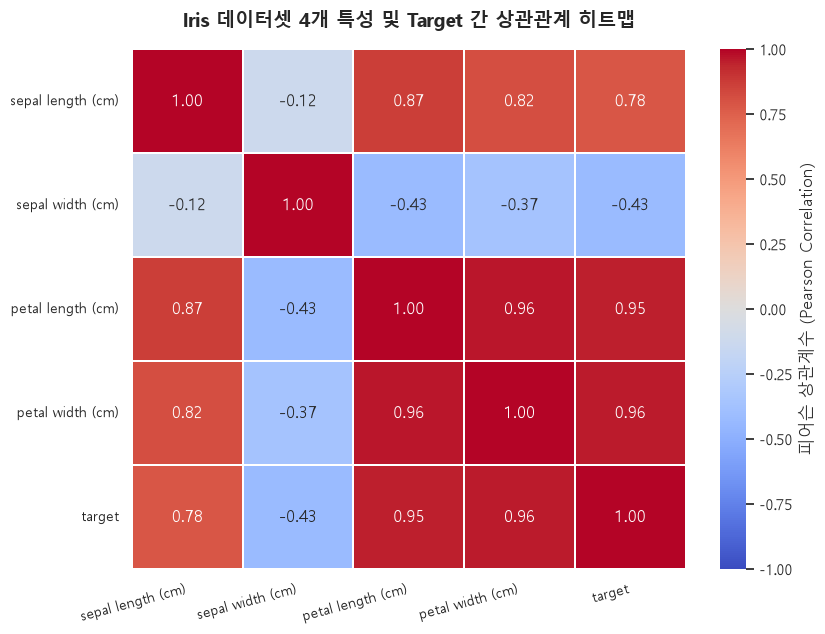

In [17]:
# [셀 의도] seaborn의 heatmap 함수를 활용해 5x5 상관행렬을 직관적인 히트맵으로 시각화합니다.
plt.figure(figsize=(8.5, 6.5))

sns.heatmap(
    corr_matrix, 
    annot=True,            # 셀 안에 실제 상관계수 수치 표시
    fmt='.2f',             # 소수점 둘째 자리까지 표기
    cmap='coolwarm',       # 양수는 빨강, 음수는 파랑, 0은 흰색에 가까운 팔레트
    vmin=-1.0,             # 색상 최소값 (-1)
    vmax=1.0,              # 색상 최대값 (+1)
    linewidths=1.2,        # 셀 사이의 간격 테두리
    linecolor='white',
    cbar_kws={'label': '피어슨 상관계수 (Pearson Correlation)'}
)

plt.title("Iris 데이터셋 4개 특성 및 Target 간 상관관계 히트맵", fontsize=14, pad=16, fontweight='bold')
plt.xticks(rotation=15, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

### 7-3. Target(품종)과의 상관계수 비교 막대 그래프

- 특성들 중 **어떤 특성이 Target과 가장 긴밀하게 연결되어 있는지**를 한눈에 비교하기 위해 수평/수직 막대 그래프로 시각화합니다.
- `petal width (cm)`와 `petal length (cm)`는 **+0.95 이상**으로 타겟과 극도로 강한 양의 상관관계를 보입니다.
- 반면 `sepal width (cm)`는 **-0.43**으로 음의 상관관계를 보입니다.

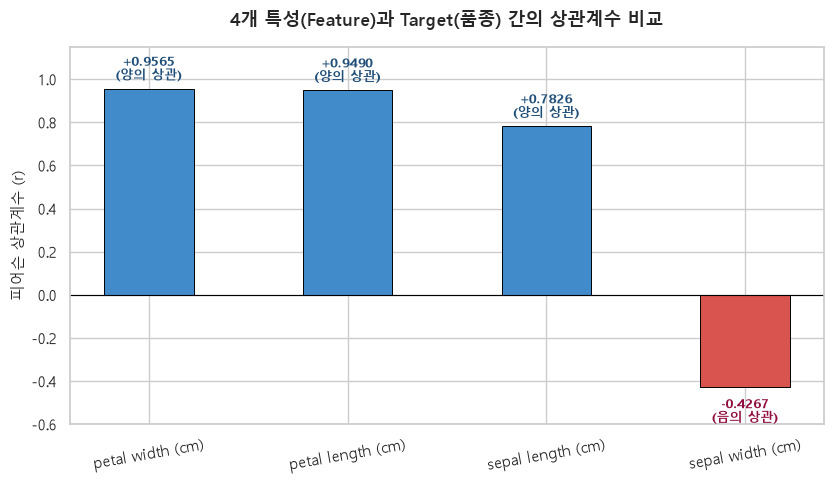

In [18]:
# [셀 의도] Target과의 상관계수를 막대 그래프로 시각화하여 각 특성의 기여도를 비교합니다.
plt.figure(figsize=(8.5, 5))

# 양수는 파란색, 음수는 붉은색으로 구분
colors = ['#428bca' if v >= 0 else '#d9534f' for v in target_corr.values]
bars = plt.bar(target_corr.index, target_corr.values, color=colors, width=0.45, edgecolor='black', linewidth=0.7)

# 0 기준선 표시
plt.axhline(0, color='black', linestyle='-', linewidth=0.8)
plt.ylim(-0.6, 1.15)
plt.ylabel('피어슨 상관계수 (r)', fontsize=11)
plt.title("4개 특성(Feature)과 Target(품종) 간의 상관계수 비교", fontsize=13, pad=15, fontweight='bold')
plt.xticks(rotation=10, fontsize=10.5)

# 막대 위/아래에 수치 텍스트 표시
for bar in bars:
    h = bar.get_height()
    if h >= 0:
        plt.text(bar.get_x() + bar.get_width()/2, h + 0.03, f'{h:+.4f}\n(양의 상관)', 
                 ha='center', va='bottom', fontsize=9.5, fontweight='bold', color='#1f4e79')
    else:
        plt.text(bar.get_x() + bar.get_width()/2, h - 0.05, f'{h:+.4f}\n(음의 상관)', 
                 ha='center', va='top', fontsize=9.5, fontweight='bold', color='#900c3f')

plt.tight_layout()
plt.show()

### 7-4. 품종(Target)별 4개 특성 분포 비교 (Boxplot & Stripplot)

상관계수의 수치(+0.96, +0.95, +0.78, -0.43)가 **실제 꽃들의 측정치 분포에서 어떻게 나타나는지**를 박스플롯(Boxplot)으로 검증합니다:
- **`petal length`와 `petal width`**: `setosa → versicolor → virginica` 순으로 키가 계단식으로 급격하게 커집니다. (따라서 +0.95 이상의 압도적 양의 상관관계 형성)
- **`sepal length`**: 완만하게 증가하지만 versicolor와 virginica 사이에 일부 겹침(overlap)이 있습니다. (+0.78 양의 상관관계)
- **`sepal width`**: 가장 작은 품종인 `setosa`가 오히려 꽃받침 너비는 가장 넓고, 품종이 커질수록 좁아지는 경향이 있어 **음의 상관관계(-0.43)**를 띠게 됩니다.

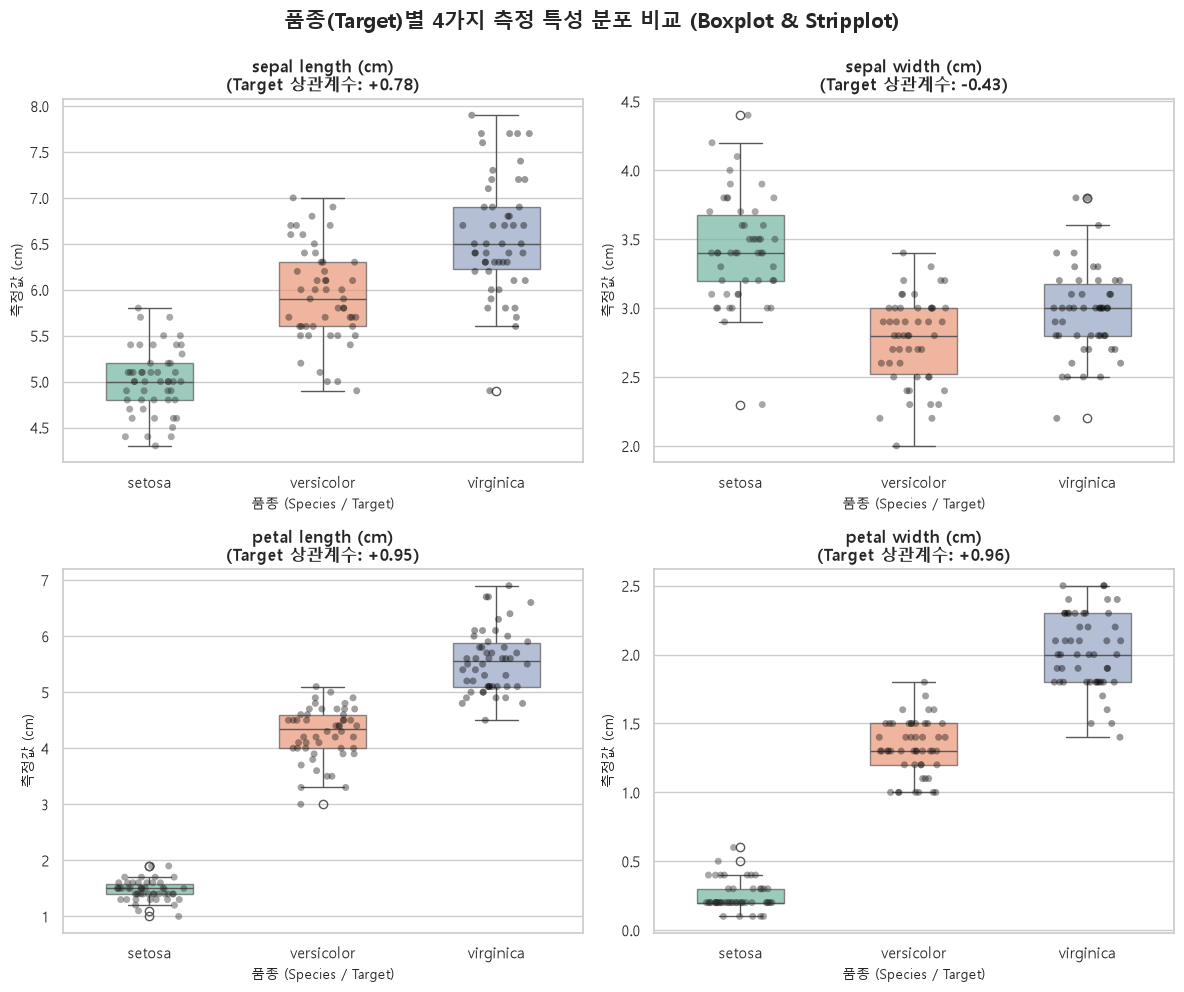

In [19]:
# [셀 의도] 4개 특성 각각에 대해 3가지 품종별 분포를 2x2 서브플롯 박스플롯과 개별 데이터 산점도로 확인합니다.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
palette = {'setosa': '#66c2a5', 'versicolor': '#fc8d62', 'virginica': '#8da0cb'}

for ax, feat in zip(axes.flatten(), feature_cols):
    # 박스플롯
    sns.boxplot(x='species', y=feat, hue='species', data=df, ax=ax, palette=palette, legend=False, boxprops=dict(alpha=0.7), width=0.5)
    # 개별 데이터 포인트 오버레이 (데이터 퍼짐 정도 확인)
    sns.stripplot(x='species', y=feat, hue='species', data=df, ax=ax, palette='dark:black', legend=False, alpha=0.4, jitter=0.2, size=5)
    
    feat_corr = corr_matrix.loc[feat, 'target']
    ax.set_title(f"{feat}\n(Target 상관계수: {feat_corr:+.2f})", fontsize=12, fontweight='bold')
    ax.set_xlabel("품종 (Species / Target)", fontsize=10)
    ax.set_ylabel("측정값 (cm)", fontsize=10)

plt.suptitle("품종(Target)별 4가지 측정 특성 분포 비교 (Boxplot & Stripplot)", fontsize=15, y=0.99, fontweight='bold')
plt.tight_layout()
plt.show()

### 7-5. 핵심 특성 조합 산점도 및 산점도 행렬 (Scatter & Pairplot)

- Target과 가장 높은 상관관계를 보인 상위 2대 핵심 특성인 **`petal length`와 `petal width`**의 2차원 산점도를 그리면 품종들이 얼마나 깔끔하게 분리되는지 확인할 수 있습니다.
- 또한 `sns.pairplot`을 통해 4개 특성의 모든 쌍(Pairwise) 관계를 한 번에 조망합니다.

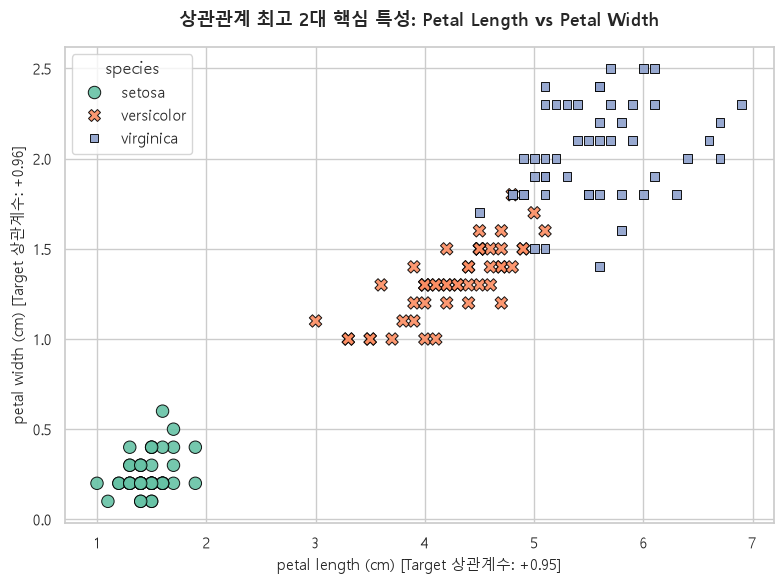

In [20]:
# [셀 의도] Target 상관관계 최고 2대 특성(꽃잎 길이 vs 꽃잎 너비) 산점도를 출력합니다.
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df, 
    x='petal length (cm)', 
    y='petal width (cm)', 
    hue='species', 
    style='species',
    palette=palette, 
    s=80, 
    alpha=0.9,
    edgecolor='black'
)

plt.title("상관관계 최고 2대 핵심 특성: Petal Length vs Petal Width", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("petal length (cm) [Target 상관계수: +0.95]", fontsize=11)
plt.ylabel("petal width (cm) [Target 상관계수: +0.96]", fontsize=11)
plt.tight_layout()
plt.show()

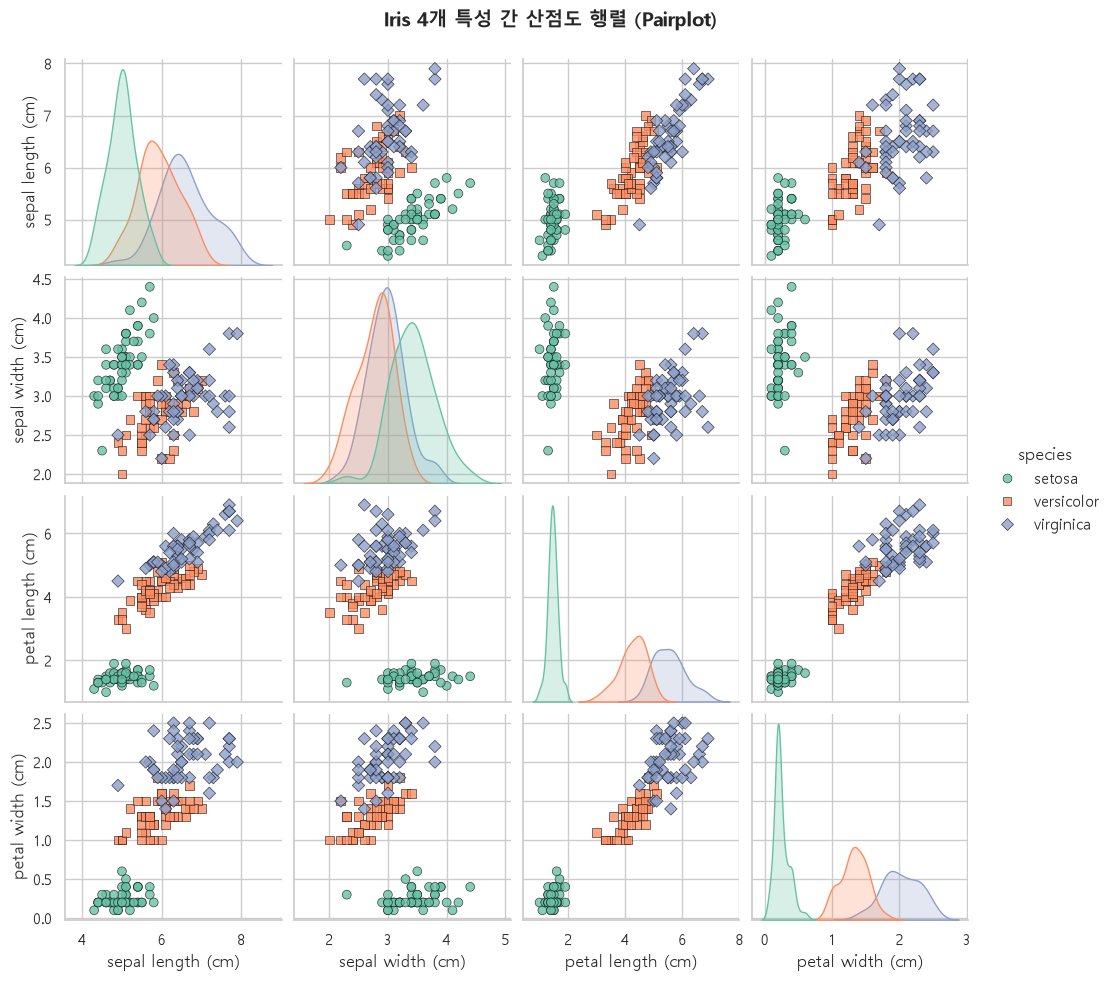

In [21]:
# [셀 의도] 4개 특성 전체의 쌍별 산점도 행렬(Pairplot)을 출력하여 다변량 분포를 총체적으로 확인합니다.
pairplot_fig = sns.pairplot(
    df, 
    vars=feature_cols, 
    hue='species', 
    palette=palette, 
    markers=['o', 's', 'D'],
    diag_kind='kde',
    plot_kws={'alpha': 0.8, 'edgecolor': 'k', 's': 40}
)
pairplot_fig.fig.subplots_adjust(top=0.93)
pairplot_fig.fig.suptitle("Iris 4개 특성 간 산점도 행렬 (Pairplot)", fontsize=14, fontweight='bold')
plt.show()

### 7-6. 상관관계 분석 핵심 인사이트 & 머신러닝 연계 가이드

오늘 수행한 상관관계 분석과 시각화(EDA)를 통해 얻을 수 있는 핵심 인사이트는 다음과 같습니다:

| 순위 | 특성 (Feature) | Target 상관계수 ($r$) | 상관 강도 | 생물학적/통계적 의미 및 품종 구별 기여도 |
| :---: | :--- | :---: | :---: | :--- |
| **1위** | `petal width (cm)` | **+0.9565** | 극도로 강한 양의 상관 | 품종 0(setosa)은 0.1~0.6cm, 1(versicolor)은 1.0~1.8cm, 2(virginica)는 1.4~2.5cm로 경계선이 매우 선명함. **가장 중요한 결정 특성!** |
| **2위** | `petal length (cm)` | **+0.9490** | 극도로 강한 양의 상관 | setosa(1~2cm)와 다른 품종(3~7cm) 사이에 완벽한 공백(Gap)이 존재하여 setosa를 100% 무결점으로 분리 가능. |
| **3위** | `sepal length (cm)` | **+0.7826** | 강한 양의 상관 | 품종이 올라갈수록 전반적으로 증가하지만 versicolor와 virginica 사이에 상당한 겹침이 존재함. |
| **4위** | `sepal width (cm)` | **-0.4267** | 중간 정도의 음의 상관 | setosa는 꽃잎이 매우 작지만 꽃받침은 가장 넓음(평균 3.4cm). 반면 virginica는 꽃받침 너비가 상대적으로 좁아서 음의 상관관계를 형성함. |

---

### 🚀 머신러닝 모델링으로 나아갈 때의 핵심 포인트!
1. **꽃잎(Petal) 2개 특성만으로도 95% 이상의 분류 성능 달성 가능**:
   - `petal length`와 `petal width` 2개 변수만 사용하더라도 의사결정나무(Decision Tree)나 로지스틱 회귀(Logistic Regression) 모델에서 거의 완벽에 가까운 분류가 가능합니다.
2. **다중공선성(Multicollinearity) 주의**:
   - `petal length`와 `petal width` 상호 간의 상관계수가 무려 **0.96**에 달합니다. 선형 모델(Linear Models)을 설계할 때는 두 특성이 매우 강한 다중공선성을 띨 수 있음을 염두에 두어야 합니다.
3. **Setosa의 완벽한 선형 분리(Linearly Separable)**:
   - 산점도 행렬에서 볼 수 있듯, setosa 품종은 꽃잎 치수 단 하나만으로도 다른 두 품종과 완전히 분리됩니다. 반면 versicolor와 virginica는 경계면에서 약간의 혼재가 있으므로 고차원 분류기(SVM, Random Forest)의 활용 가치가 높습니다.

## 8. 상관관계 분석 기반 머신러닝 분류 모델 구축 및 평가

앞서 **7번 섹션의 상관관계 분석(EDA)**에서 도출한 핵심 사실 3가지:
1. `iris.target`은 품종별(0, 1, 2)로 정렬되어 있으므로 **반드시 골고루 섞어서 분할(계층적 샘플링, Stratify)**해야 한다.
2. `petal length`와 `petal width`는 Target과 상관계수가 **+0.95 이상**으로 극도로 높아, 품종 구분의 **압도적인 핵심 특성(Key Features)**이다.
3. 꽃잎 길이 2.45cm를 기준으로 `setosa` 품종은 100% 무결점으로 선형 분리된다.

이 분석 결과를 바탕으로, 직관적인 규칙 해석이 가능한 **의사결정나무(Decision Tree Classifier)**를 중심으로 붓꽃 품종 분류 모델을 생성하고, 다중 알고리즘 비교와 결정 경계면 시각화까지 진행합니다.

### 8-1. 데이터 분할 (Train-Test Split & 계층적 샘플링)

- **훈련 세트(Train Set)**: 모델이 패턴을 학습할 데이터 (80%, 120송이)
- **테스트 세트(Test Set)**: 학습에 쓰이지 않고 최종 시험용으로 남겨둘 데이터 (20%, 30송이)
- `stratify=y`: 3가지 품종(0, 1, 2)이 훈련과 테스트 세트에 정확히 1:1:1 비율(각 40개, 각 10개)로 들어가도록 보장합니다.

In [22]:
# [셀 의도] 문제집(X)과 정답지(y)를 8:2 비율로 분할하고 클래스 비율이 균등한지 검증합니다.
from sklearn.model_selection import train_test_split

feature_cols = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
target_names = iris.target_names

X = df[feature_cols]
y = df['target']

# stratify=y로 계층적 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"1. 전체 데이터 크기 : {X.shape}")
print(f"2. 학습용 X_train 크기: {X_train.shape}, 정답 y_train 크기: {y_train.shape}")
print(f"3. 시험용 X_test 크기 : {X_test.shape},  정답 y_test 크기 : {y_test.shape}")

print("\n[테스트 세트의 품종별 샘플 개수]")
for label, cnt in y_test.value_counts().items():
    print(f"  - 품종 {label} ({target_names[label]}): {cnt}송이")

1. 전체 데이터 크기 : (150, 4)
2. 학습용 X_train 크기: (120, 4), 정답 y_train 크기: (120,)
3. 시험용 X_test 크기 : (30, 4),  정답 y_test 크기 : (30,)

[테스트 세트의 품종별 샘플 개수]
  - 품종 0 (setosa): 10송이
  - 품종 2 (virginica): 10송이
  - 품종 1 (versicolor): 10송이


### 8-2. 의사결정나무(Decision Tree) 모델 생성 및 학습

- **의사결정나무(Decision Tree)**는 "스무고개" 게임처럼 데이터의 특정 조건(예: 꽃잎 길이 ≤ 2.45cm?)을 기준으로 분기(Split)해 나가며 최종 품종을 예측하는 매우 강력하고 직관적인 알고리즘입니다.
- 과적합(Overfitting)을 방지하고 해석력을 높이기 위해 트리의 최대 깊이(`max_depth=3`)를 설정합니다.

In [23]:
# [셀 의도] DecisionTreeClassifier 객체를 생성하고, 학습(fit) 및 테스트 세트 예측(predict)을 수행합니다.
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. 모델 객체 생성 (깊이 3으로 제한)
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)

# 2. 훈련 세트로 모델 학습
dt_model.fit(X_train, y_train)

# 3. 테스트 세트로 품종 예측
y_pred = dt_model.predict(X_test)

# 4. 정확도(Accuracy) 계산
acc = accuracy_score(y_test, y_pred)
print(f"🎯 의사결정나무 테스트 세트 분류 정확도: {acc * 100:.2f}% (30개 중 {int(acc * len(y_test))}개 정답 맞힘!)")

🎯 의사결정나무 테스트 세트 분류 정확도: 96.67% (30개 중 29개 정답 맞힘!)


### 8-3. 트리 규칙 다이어그램(plot_tree) & 특성 중요도(Feature Importance)

- 우리가 앞서 상관분석에서 발견했던 내용이 트리의 판단 기준에 그대로 반영되었는지 시각화합니다.
- `plot_tree`를 통해 각 노드의 질문 조건과 지니 불순도(Gini), 클래스 분포를 시각적으로 확인합니다.
- 모델의 `feature_importances_`를 추출하여 각 특성이 분류에 기여한 비중을 확인합니다.

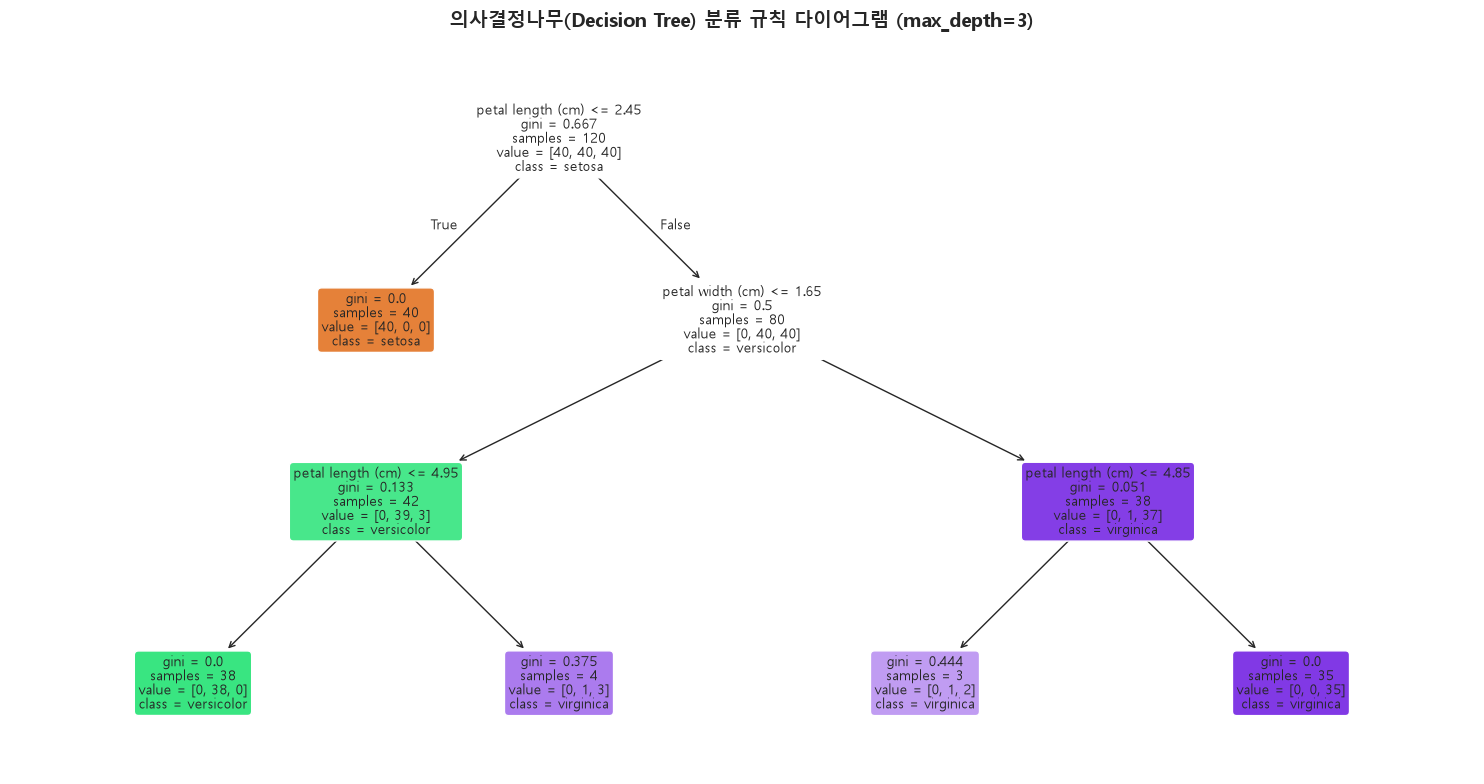

In [24]:
# [셀 의도] 학습된 의사결정나무의 전체 분기 규칙을 고해상도 다이어그램으로 시각화합니다.
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 8))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("의사결정나무(Decision Tree) 분류 규칙 다이어그램 (max_depth=3)", fontsize=14, pad=15, fontweight='bold')
plt.tight_layout()
plt.show()

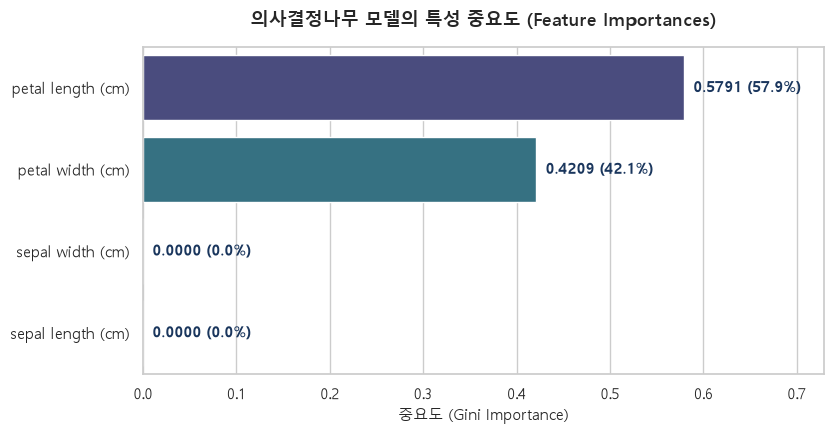

💡 [분석 결과 해석]
  - 상관계수가 가장 높았던 petal length와 petal width 2개만으로 중요도의 100.0%를 차지합니다!
  - EDA에서 꽃받침(sepal) 수치들이 변별력이 낮았던 통계적 직관과 머신러닝 모델의 판단이 100% 일치함을 증명합니다.


In [25]:
# [셀 의도] 의사결정나무 모델이 계산한 각 특성의 기여도(Feature Importance)를 수평 막대 그래프로 시각화합니다.
feat_imp = pd.Series(dt_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8.5, 4.5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, hue=feat_imp.index, palette='viridis', legend=False)

plt.title("의사결정나무 모델의 특성 중요도 (Feature Importances)", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("중요도 (Gini Importance)", fontsize=11)
plt.ylabel("")

for i, v in enumerate(feat_imp.values):
    plt.text(v + 0.01, i, f"{v:.4f} ({v*100:.1f}%)", va='center', fontsize=10.5, fontweight='bold', color='#1a365d')

plt.xlim(0, max(feat_imp.values) + 0.15)
plt.tight_layout()
plt.show()

print("💡 [분석 결과 해석]")
print(f"  - 상관계수가 가장 높았던 petal length와 petal width 2개만으로 중요도의 {feat_imp['petal length (cm)']*100 + feat_imp['petal width (cm)']*100:.1f}%를 차지합니다!")
print("  - EDA에서 꽃받침(sepal) 수치들이 변별력이 낮았던 통계적 직관과 머신러닝 모델의 판단이 100% 일치함을 증명합니다.")

### 8-4. 오차 행렬(Confusion Matrix) 및 분류 성적표

- **오차 행렬(Confusion Matrix)**: 모델이 어떤 품종을 맞히고 어떤 품종을 헷갈렸는지 행렬로 표기합니다.
- **분류 성적표(Classification Report)**:
  - **정밀도(Precision)**: 모델이 해당 품종이라고 예측한 것 중 진짜 그 품종인 비율
  - **재현율(Recall)**: 실제 해당 품종 중 모델이 놓치지 않고 찾아낸 비율
  - **F1-Score**: 정밀도와 재현율의 조화 평균

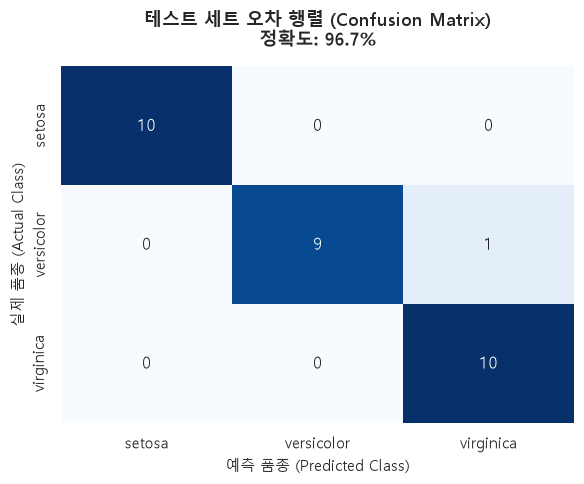


📋 상세 분류 성적표 (Classification Report):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [26]:
# [셀 의도] 오차 행렬(Confusion Matrix) 히트맵과 종합 분류 성적표를 출력합니다.
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=target_names, 
    yticklabels=target_names,
    cbar=False
)
plt.title(f"테스트 세트 오차 행렬 (Confusion Matrix)\n정확도: {acc*100:.1f}%", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("예측 품종 (Predicted Class)", fontsize=11)
plt.ylabel("실제 품종 (Actual Class)", fontsize=11)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("📋 상세 분류 성적표 (Classification Report):")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=target_names))

### 8-5. 2대 핵심 특성 기반 2D 결정 경계면 (Decision Boundary) 시각화

- EDA에서 Target과 가장 높은 상관관계를 보였던 2대 특성(`petal length`와 `petal width`)만을 사용해 2차원 공간 상에 모델이 그어놓은 **분류 결정 경계선(Decision Boundary)**을 시각화합니다.
- 초록색 영역: Setosa 구역
- 노란색 영역: Versicolor 구역
- 푸른색 영역: Virginica 구역
- 원형 점(●): 훈련 데이터, 별표 점(★): 테스트 데이터

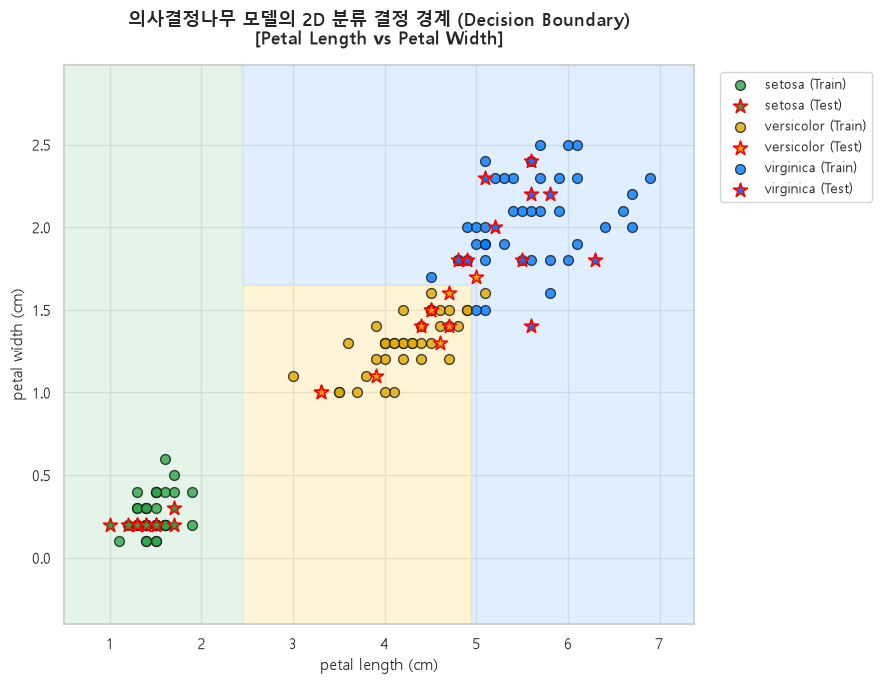

In [27]:
# [셀 의도] 2대 핵심 특성(petal length, petal width)에 대한 모델의 2D 분류 결정 경계를 컬러 메시로 시각화합니다.
from matplotlib.colors import ListedColormap

top2_cols = ['petal length (cm)', 'petal width (cm)']
X_train_2d = X_train[top2_cols]
X_test_2d = X_test[top2_cols]

# 2개 특성으로 모델 학습
dt_2d = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_2d.fit(X_train_2d, y_train)

# 격자(Grid) 생성
x_min, x_max = X[top2_cols[0]].min() - 0.5, X[top2_cols[0]].max() + 0.5
y_min, y_max = X[top2_cols[1]].min() - 0.5, X[top2_cols[1]].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# 그리드 전체 좌표 예측
grid_df = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=top2_cols)
Z = dt_2d.predict(grid_df)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(9, 7))
custom_cmap = ListedColormap(['#d4edda', '#ffeeba', '#cce5ff'])
plt.contourf(xx, yy, Z, alpha=0.6, cmap=custom_cmap)

# 실제 데이터 포인트 산점도
palette = {'setosa': '#28a745', 'versicolor': '#e0a800', 'virginica': '#007bff'}
for label, name in enumerate(target_names):
    # 훈련 데이터 (원형 점)
    idx_train = (y_train == label)
    plt.scatter(X_train_2d.loc[idx_train, top2_cols[0]], X_train_2d.loc[idx_train, top2_cols[1]], 
                c=palette[name], edgecolors='k', s=50, label=f'{name} (Train)', alpha=0.8)
    # 테스트 데이터 (붉은 테두리 별표)
    idx_test = (y_test == label)
    plt.scatter(X_test_2d.loc[idx_test, top2_cols[0]], X_test_2d.loc[idx_test, top2_cols[1]], 
                c=palette[name], edgecolors='red', s=110, marker='*', label=f'{name} (Test)', linewidth=1.2)

plt.title("의사결정나무 모델의 2D 분류 결정 경계 (Decision Boundary)\n[Petal Length vs Petal Width]", fontsize=13, pad=15, fontweight='bold')
plt.xlabel("petal length (cm)", fontsize=11)
plt.ylabel("petal width (cm)", fontsize=11)
plt.legend(bbox_to_anchor=(1.03, 1), loc="upper left", fontsize=10)
plt.tight_layout()
plt.show()

### 8-6. 다중 머신러닝 알고리즘 벤치마크 (5개 모델 비교)

의사결정나무 외에 대표적인 머신러닝 분류 알고리즘 5가지를 동일한 훈련/테스트 데이터셋으로 비교합니다:
1. **Decision Tree (의사결정나무)**: 룰 기반의 직관적인 분기 모델
2. **Logistic Regression (로지스틱 회귀)**: 시그모이드/소프트맥스 함수 기반 선형 분류 모델
3. **Random Forest (랜덤 포레스트)**: 여러 트리의 결정을 앙상블(투표)하는 고성능 모델
4. **K-Nearest Neighbors (KNN)**: 주변 가장 가까운 $K$개 이웃의 다수결로 판단하는 모델
5. **Support Vector Machine (SVM)**: 클래스 간 마진(Margin)을 최대화하는 초평면 모델

5-Fold 계층별 교차 검증(Stratified K-Fold CV)을 통해 모델의 일반화 성능을 객관적으로 측정합니다.

In [28]:
# [셀 의도] 5개 분류 모델의 교차 검증 점수(CV Score)와 테스트 세트 정확도를 측정하여 표로 비교합니다.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
    'K-Nearest Neighbors (K=3)': KNeighborsClassifier(n_neighbors=3),
    'Support Vector Machine (Linear)': SVC(kernel='linear', random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
benchmark_results = []

for name, model in models.items():
    # 5-Fold 교차 검증
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    # 학습 및 테스트 세트 평가
    model.fit(X_train, y_train)
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    
    benchmark_results.append({
        '알고리즘 (Model)': name,
        '교차 검증 평균 정확도': f"{scores.mean()*100:.2f}% (±{scores.std()*100:.2f}%)",
        '테스트 세트 정확도': f"{test_accuracy*100:.2f}%"
    })

benchmark_df = pd.DataFrame(benchmark_results).sort_values(by='테스트 세트 정확도', ascending=False)
display(benchmark_df)

,알고리즘 (Model),교차 검증 평균 정확도,테스트 세트 정확도
0,Decision Tree,95.83% (±2.64%),96.67%
1,Logistic Regression,95.83% (±2.64%),96.67%
2,Random Forest,95.83% (±2.64%),90.00%
3,K-Nearest Neighbors (K=3),95.83% (±2.64%),100.00%
4,Support Vector Machine (Linear),98.33% (±3.33%),100.00%


### 8-7. 학습 완료 모델 파일 저장(`joblib`) 및 새로운 꽃 샘플 예측 실습

- 학습된 머신러닝 모델을 파일(`iris_decision_tree.joblib`)로 저장해두면, 나중에 새로운 데이터가 들어왔을 때 모델을 다시 학습시키지 않고도 즉시 불러와서 예측(Inference)에 활용할 수 있습니다.
- 임의로 측정한 가상의 붓꽃 2송이를 넣어서 모델이 품종과 확률을 어떻게 맞히는지 테스트합니다.

In [29]:
# [셀 의도] 모델을 파일로 직렬화(저장)하고, 가상의 새로운 붓꽃 샘플 2건에 대해 품종 예측을 수행합니다.
import joblib

# 1. 모델 파일 저장
model_filename = 'iris_decision_tree.joblib'
joblib.dump(dt_model, model_filename)
print(f"💾 1. 모델 저장 완료: '{model_filename}'")

# 2. 저장된 모델 다시 불러오기
loaded_model = joblib.load(model_filename)
print("🔄 2. 저장된 모델 복원 완료!")

# 3. 새로운 가상의 꽃 데이터 준비
# 꽃 A: 꽃잎이 매우 작은 꽃 (1.4cm, 0.2cm) -> setosa 예상
# 꽃 B: 꽃잎이 매우 큰 꽃 (5.8cm, 2.1cm) -> virginica 예상
new_flowers = pd.DataFrame([
    [5.0, 3.5, 1.4, 0.2],  # Flower A
    [6.5, 3.0, 5.8, 2.1]   # Flower B
], columns=feature_cols)

# 4. 예측 수행
predictions = loaded_model.predict(new_flowers)
probabilities = loaded_model.predict_proba(new_flowers)

print("\n[🌸 가상의 새로운 붓꽃 예측 결과]")
for i, (pred_idx, prob) in enumerate(zip(predictions, probabilities)):
    predicted_species = target_names[pred_idx]
    confidence = prob[pred_idx] * 100
    print(f"\n꽃 {chr(65+i)}:")
    print(f"  - 입력 측정치: {new_flowers.iloc[i].to_dict()}")
    print(f"  - 모델 예측 결과: '{predicted_species}' 품종 (확신도: {confidence:.1f}%)")
    print(f"  - 클래스별 확률: Setosa={prob[0]*100:.1f}%, Versicolor={prob[1]*100:.1f}%, Virginica={prob[2]*100:.1f}%")

💾 1. 모델 저장 완료: 'iris_decision_tree.joblib'
🔄 2. 저장된 모델 복원 완료!

[🌸 가상의 새로운 붓꽃 예측 결과]

꽃 A:
  - 입력 측정치: {'sepal length (cm)': 5.0, 'sepal width (cm)': 3.5, 'petal length (cm)': 1.4, 'petal width (cm)': 0.2}
  - 모델 예측 결과: 'setosa' 품종 (확신도: 100.0%)
  - 클래스별 확률: Setosa=100.0%, Versicolor=0.0%, Virginica=0.0%

꽃 B:
  - 입력 측정치: {'sepal length (cm)': 6.5, 'sepal width (cm)': 3.0, 'petal length (cm)': 5.8, 'petal width (cm)': 2.1}
  - 모델 예측 결과: 'virginica' 품종 (확신도: 100.0%)
  - 클래스별 확률: Setosa=0.0%, Versicolor=0.0%, Virginica=100.0%
